# RailCast — model training & export

**SIH26028 · Ministry of Railways.** This notebook is the Python side of RailCast: it fits
the delay-forecasting model and exports it for the browser app. The app itself does **no
fitting** — it loads the JSON produced here and only takes dot products.

**What this notebook does**
1. Load the synthetic data (`data/{trains,runs,live}.json`).
2. Engineer the same 18 predictors the browser builds, and split **by date** (never randomly).
3. Fit three tiers with `sklearn.linear_model.LinearRegression`:
   Tier 0 static schedule · Tier 1 simple regression · Tier 2 multiple regression.
4. Compute standard errors, t-stats, p-values, R², adjusted R², F, VIF and residual std
   error with **numpy** (nothing hardcoded).
5. Export `data/model.json` (inference) and `data/metrics.json` (all displayed numbers),
   plus 150-DPI plots to `ml/plots/`.

Libraries: pandas, numpy, scikit-learn, matplotlib, seaborn. Only `LinearRegression` — no
tree/neural models anywhere.

> Run order: `node data/generate.js` first (creates the data), then run this notebook.

## 1 · Imports & configuration

In [1]:
import os, json, math, statistics
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

# Resolve paths whether the notebook runs from ml/ or the repo root.
CWD = os.getcwd()
if os.path.isdir(os.path.join(CWD, "data")) and os.path.isdir(os.path.join(CWD, "ml")):
    ROOT = CWD
elif os.path.basename(CWD) == "ml":
    ROOT = os.path.dirname(CWD)
else:
    ROOT = os.path.dirname(CWD)
DATA  = os.path.join(ROOT, "data")
PLOTS = os.path.join(ROOT, "ml", "plots")
os.makedirs(PLOTS, exist_ok=True)

AVG_SPEED = 60                                   # km/h reference for padding_ratio (matches JS)
Z95 = statistics.NormalDist().inv_cdf(0.975)     # ~1.959964
print("ROOT =", ROOT)

ROOT = /Users/shubhammishra/Library/Application Support/Claude/local-agent-mode-sessions/1a4a9922-1325-4f5e-a782-1e69705a6539/f0b4273d-90da-4c3d-8764-3815f706624d/local_830c93e8-f97d-42d4-a211-d1db5e56178a/outputs/railcast


## 2 · Feature specification

A training example is a `(run, r, t)` triple: given the state at the last-reported station
**r**, predict the delay at a downstream station **t**. These 18 predictors expand to 25
columns (`type` is 3 dummies, `day_of_week` is 6). `kind` marks continuous ('c', standardised)
vs dummy ('d', left as-is). This list is identical to `js/features.js`.

In [2]:
SPEC = [
    ("current_delay_min", "c", "Delay already accrued at the last reported station — the strongest single signal; delay persists."),
    ("stations_ahead", "c", "Stops remaining to target — more stops means more chances to gain or shed delay."),
    ("km_remaining", "c", "Track distance left to run to the target station."),
    ("halt_minutes_ahead", "c", "Total scheduled halt time between here and target — halts are elastic and absorb delay."),
    ("padding_ratio", "c", "Scheduled run time / pure run time (km/avg speed); >1 means recovery slack in the timetable."),
    ("hist_delay_mean", "c", "Mean historical delay for THIS train at the target station — chronic problem stops."),
    ("hist_section_delay_mean", "c", "Mean historical delay added on the sections of the remaining route — section difficulty."),
    ("section_congestion_idx", "c", "Mean traffic congestion on the sections ahead — competes for the same track paths."),
    ("preceding_train_delay_min", "c", "Delay of the train immediately ahead — you cannot arrive before the block clears."),
    ("speed_restriction_km", "c", "Total km under temporary speed restriction ahead — engineering/weather caution orders."),
    ("delay_x_stations_ahead", "c", "current_delay x stations_ahead — a given delay matters more when far from target."),
    ("delay_x_padding_ratio", "c", "current_delay x padding_ratio — recovery slack moderates how much delay persists."),
    ("sqrt_km_remaining", "c", "sqrt(km_remaining) — delay accumulates sub-linearly with distance."),
    ("delay_squared", "c", "current_delay^2 — saturation: very large delays stop growing."),
    ("is_monsoon", "d", "June-September: monsoon degrades running everywhere."),
    ("is_night_run", "d", "Departure 22:00-05:00: fewer paths but also freight windows; distinct regime."),
    ("type_rajdhani", "d", "Train type = Rajdhani (Passenger is the reference level)."),
    ("type_superfast", "d", "Train type = Superfast (reference: Passenger)."),
    ("type_express", "d", "Train type = Express (reference: Passenger)."),
    ("dow_mon", "d", "Monday (reference: Sunday)."),
    ("dow_tue", "d", "Tuesday (reference: Sunday)."),
    ("dow_wed", "d", "Wednesday (reference: Sunday)."),
    ("dow_thu", "d", "Thursday (reference: Sunday)."),
    ("dow_fri", "d", "Friday (reference: Sunday)."),
    ("dow_sat", "d", "Saturday (reference: Sunday)."),
]
NAMES = [s[0] for s in SPEC]
KIND = {s[0]: s[1] for s in SPEC}
RATIONALE = {s[0]: s[2] for s in SPEC}
COLUMN_NAMES = ["intercept"] + NAMES
CONT = [n for n in NAMES if KIND[n] == "c"]
print(len(NAMES), "predictors ->", len(COLUMN_NAMES), "columns incl. intercept")

25 predictors -> 26 columns incl. intercept


## 3 · Load & index the data

In [3]:
def load_json(name):
    with open(os.path.join(DATA, name)) as f:
        return json.load(f)

trains_raw = load_json("trains.json")
runs       = load_json("runs.json")
live       = load_json("live.json")

def to_min(hm):
    if not hm: return None
    h, m = hm.split(":"); return int(h) * 60 + int(m)

def index_trains(trains_raw):
    # parse schedules into absolute minutes with overnight wrap (mirrors JS)
    trains = {}
    for no, t in trains_raw.items():
        stations = [dict(s) for s in t["stations"]]
        base, prev = 0, None
        for s in stations:
            arr, dep = to_min(s["sched_arr"]), to_min(s["sched_dep"])
            if arr is not None:
                if prev is not None and arr + base < prev: base += 1440
                arr += base; prev = arr
            if dep is not None:
                if prev is not None and dep + base < prev: base += 1440
                dep = dep + base; prev = dep
            s["_arrMin"], s["_depMin"] = arr, dep
        trains[no] = {"train_no": no, "name": t["name"], "type": t["type"], "stations": stations}
    return trains

def index_runs(runs):
    by_train = {}
    for r in runs:
        by_train.setdefault(r["train_no"], {}).setdefault(r["run_date"], {})[r["station_seq"]] = r
    return by_train

trains_idx = index_trains(trains_raw)
by_train   = index_runs(runs)
print(len(trains_idx), "trains,", len(runs), "station-arrival records")

39 trains, 32352 station-arrival records


## 4 · Date-based train/test split

We hold out the most recent ~20% of days. **Never random** — shuffling would leak a train's
later state into its own earlier prediction and leak future days into the past.

In [4]:
all_dates = sorted({r["run_date"] for r in runs})
cut = int(len(all_dates) * 0.8)
train_dates = set(all_dates[:cut])
test_dates  = set(all_dates[cut:])
split_date  = all_dates[cut]
print(f"{len(train_dates)} train days / {len(test_dates)} test days; first test day = {split_date}")

76 train days / 20 test days; first test day = 2026-07-16


## 5 · Historical lookups (training split only)

Per-`(train, station)` means used both as model features and, later, exported so the browser
can build the same features for live trains without recomputing anything.

In [5]:
class History:
    def __init__(self):
        self.station_delay, self.section_added = {}, {}
        self.cong, self.prec, self.sr = {}, {}, {}
    def station_mean(self, no, seq):
        return self.station_delay.get(no, {}).get(seq, 0.0)
    def segment_mean(self, no, r, t):
        s, c = 0.0, 0
        for q in range(r + 1, t + 1):
            s += self.section_added.get(no, {}).get(q, 0.0); c += 1
        return s / c if c else 0.0
    def as_lookups(self):
        def sk(d): return {no: {str(k): float(v) for k, v in inner.items()} for no, inner in d.items()}
        return {"stationDelayMean": sk(self.station_delay), "sectionAddedMean": sk(self.section_added),
                "congMean": sk(self.cong), "precMean": sk(self.prec), "srMean": sk(self.sr)}

def build_history(by_train, train_dates):
    hist, acc = History(), {}
    for no, dates in by_train.items():
        for date, seqmap in dates.items():
            if date not in train_dates: continue
            for seq, rec in seqmap.items():
                b = acc.setdefault(no, {}).setdefault(seq, {"delay": [], "add": [], "cong": [], "prec": [], "sr": []})
                b["delay"].append(rec["delay_min"]); b["cong"].append(rec["section_congestion_idx"])
                b["prec"].append(rec["preceding_train_delay_min"]); b["sr"].append(rec["speed_restriction_km"])
                prev = seqmap.get(seq - 1)
                if prev is not None: b["add"].append(rec["delay_min"] - prev["delay_min"])
    for no, seqs in acc.items():
        for seq, b in seqs.items():
            hist.station_delay.setdefault(no, {})[seq] = float(np.mean(b["delay"])) if b["delay"] else 0.0
            hist.section_added.setdefault(no, {})[seq] = float(np.mean(b["add"]))  if b["add"]  else 0.0
            hist.cong.setdefault(no, {})[seq] = float(np.mean(b["cong"])) if b["cong"] else 0.4
            hist.prec.setdefault(no, {})[seq] = float(np.mean(b["prec"])) if b["prec"] else 0.0
            hist.sr.setdefault(no, {})[seq]   = float(np.mean(b["sr"]))   if b["sr"]   else 0.0
    return hist

hist = build_history(by_train, train_dates)
print("history built for", len(hist.station_delay), "trains")

history built for 39 trains


## 6 · Feature engineering & example construction

In [6]:
def padding_ahead(stations, r, t):
    # available recovery padding between seq r and t (Tier-0 baseline)
    pad = 0.0
    for q in range(r + 1, t + 1):
        a, b = stations[q - 1], stations[q - 2]
        pure = ((a["km"] - b["km"]) / AVG_SPEED) * 60
        pad += max(0.0, (a["_arrMin"] - b["_depMin"]) - pure)
    return pad

def raw_features(train, stations, r, t, hist, ctx):
    sr, st = stations[r - 1], stations[t - 1]
    km_remaining = st["km"] - sr["km"]
    halt_ahead = sum((stations[q].get("halt_min", 0) or 0) for q in range(r, t - 1))  # seq r+1..t-1
    sched_run = st["_arrMin"] - sr["_depMin"]
    pure_run  = (km_remaining / AVG_SPEED) * 60
    padding_ratio = sched_run / pure_run if pure_run > 0 else 1.0
    cur, typ, dow = ctx["current_delay_min"], train["type"], ctx["day_of_week"]
    return {
        "current_delay_min": cur, "stations_ahead": t - r, "km_remaining": km_remaining,
        "halt_minutes_ahead": halt_ahead, "padding_ratio": padding_ratio,
        "hist_delay_mean": hist.station_mean(train["train_no"], t),
        "hist_section_delay_mean": hist.segment_mean(train["train_no"], r, t),
        "section_congestion_idx": ctx["section_congestion_idx"],
        "preceding_train_delay_min": ctx["preceding_train_delay_min"],
        "speed_restriction_km": ctx["speed_restriction_km"],
        "delay_x_stations_ahead": cur * (t - r), "delay_x_padding_ratio": cur * padding_ratio,
        "sqrt_km_remaining": np.sqrt(max(0.0, km_remaining)), "delay_squared": cur * cur,
        "is_monsoon": ctx["is_monsoon"], "is_night_run": ctx["is_night_run"],
        "type_rajdhani": int(typ == "Rajdhani"), "type_superfast": int(typ == "Superfast"),
        "type_express": int(typ == "Express"),
        "dow_mon": int(dow == 1), "dow_tue": int(dow == 2), "dow_wed": int(dow == 3),
        "dow_thu": int(dow == 4), "dow_fri": int(dow == 5), "dow_sat": int(dow == 6),
    }

def ctx_from_run(train, seqmap, r, t):
    r_rec, t_rec = seqmap[r], seqmap[t]
    cong, sr, cnt = 0.0, 0.0, 0
    for q in range(r + 1, t + 1):
        rec = seqmap.get(q)
        if rec is not None:
            cong += rec["section_congestion_idx"]; sr += rec["speed_restriction_km"]; cnt += 1
    dep_hour = int((train["stations"][0]["_depMin"] % 1440) // 60)
    return {"current_delay_min": r_rec["delay_min"],
            "section_congestion_idx": cong / cnt if cnt else 0.4,
            "preceding_train_delay_min": t_rec["preceding_train_delay_min"],
            "speed_restriction_km": sr, "day_of_week": t_rec["day_of_week"],
            "is_monsoon": int(6 <= t_rec["month"] <= 9),
            "is_night_run": int(dep_hour >= 22 or dep_hour < 5)}

def build_examples(date_set, rng):
    # one reference r (random earlier station) per target t — covers all lead times
    rows, meta = [], []
    for no, dates in by_train.items():
        train = trains_idx[no]; n_st = len(train["stations"])
        for date, seqmap in dates.items():
            if date not in date_set: continue
            for t in range(2, n_st + 1):
                if t not in seqmap: continue
                r = 1 + int(rng.integers(0, t - 1))
                if r not in seqmap: continue
                ctx = ctx_from_run(train, seqmap, r, t)
                rows.append(raw_features(train, train["stations"], r, t, hist, ctx))
                meta.append({"no": no, "date": date, "r": r, "t": t, "type": train["type"],
                             "stations_ahead": t - r, "y": seqmap[t]["delay_min"]})
    return rows, meta

rng = np.random.default_rng(20260827)
train_rows, train_meta = build_examples(train_dates, rng)
test_rows,  test_meta  = build_examples(test_dates, rng)
df_tr = pd.DataFrame(train_rows); df_te = pd.DataFrame(test_rows)
y_tr = np.array([m["y"] for m in train_meta], float)
y_te = np.array([m["y"] for m in test_meta], float)
lead_tr = np.array([m["stations_ahead"] for m in train_meta])
lead_te = np.array([m["stations_ahead"] for m in test_meta])
print(f"examples: {len(train_meta)} train / {len(test_meta)} test")
df_tr.head()

examples: 22648 train / 5960 test


,current_delay_min,stations_ahead,km_remaining,halt_minutes_ahead,padding_ratio,hist_delay_mean,hist_section_delay_mean,section_congestion_idx,preceding_train_delay_min,speed_restriction_km,...,is_night_run,type_rajdhani,type_superfast,type_express,dow_mon,dow_tue,dow_wed,dow_thu,dow_fri,dow_sat
0,4,1,69,0,0.898551,9.986842,4.750000,0.557000,8,0.0,...,0,0,1,0,0,0,0,0,1,0
1,10,1,60,0,0.900000,14.342105,4.355263,0.458000,11,0.0,...,0,0,1,0,0,0,0,0,1,0
2,10,2,146,5,0.938356,11.828947,0.921053,0.434000,7,0.0,...,0,0,1,0,0,0,0,0,1,0
3,10,3,266,8,0.936090,11.421053,0.478070,0.476667,4,0.0,...,0,0,1,0,0,0,0,0,1,0
4,2,2,75,3,20.160000,18.026316,3.098684,0.458000,4,6.0,...,0,0,1,0,0,0,0,0,1,0


## 7 · Standardisation & design matrices

Continuous predictors are standardised with the **training** mean/SD (ddof=1); dummies pass
through. `X_design` prepends the intercept column.

In [7]:
mean = {c: float(df_tr[c].mean()) for c in CONT}
std  = {c: float(df_tr[c].std(ddof=1)) or 1.0 for c in CONT}

def design(df):
    Z = df[NAMES].copy()
    for c in CONT: Z[c] = (Z[c] - mean[c]) / std[c]
    Xpred = Z.values.astype(float)
    Xdes  = np.hstack([np.ones((len(Xpred), 1)), Xpred])
    return Xpred, Xdes

Xpred_tr, Xdes_tr = design(df_tr)
Xpred_te, Xdes_te = design(df_te)
print("design matrix:", Xdes_tr.shape)

design matrix: (22648, 26)


## 8 · Fit the three tiers (scikit-learn)

- **Tier 2** multiple regression, on raw `y` and on `log(y+1)` (compared later).
- **Tier 1** simple regression on standardised `current_delay_min`.
- **Tier 0** static schedule: `max(0, current_delay − recovery padding)`.

In [8]:
lr_raw = LinearRegression(fit_intercept=True).fit(Xpred_tr, y_tr)
beta_raw = np.concatenate([[lr_raw.intercept_], lr_raw.coef_])

y_tr_log = np.log(np.maximum(y_tr, 0.0) + 1.0)
lr_log = LinearRegression(fit_intercept=True).fit(Xpred_tr, y_tr_log)
beta_log = np.concatenate([[lr_log.intercept_], lr_log.coef_])

cd = "current_delay_min"
Xs_tr = (df_tr[[cd]].values - mean[cd]) / std[cd]
Xs_te = (df_te[[cd]].values - mean[cd]) / std[cd]
lr_simple = LinearRegression(fit_intercept=True).fit(Xs_tr, y_tr)

def static_pred(meta_list, rows):
    out = []
    for m, raw in zip(meta_list, rows):
        pad = padding_ahead(trains_idx[m["no"]]["stations"], m["r"], m["t"])
        out.append(max(0.0, raw["current_delay_min"] - pad))
    return np.array(out)

print("fitted: tier2(raw), tier2(log), tier1(simple); tier0 is closed-form")

fitted: tier2(raw), tier2(log), tier1(simple); tier0 is closed-form


## 9 · OLS inference with numpy

`sklearn` gives the coefficients; every inference statistic is derived here from X and y.
`se = sqrt(sigma^2 * diag((X'X)^-1))`, plus R², adjusted R², F, and VIF (regress each predictor
on the others). p-values use a normal approximation to Student's t (df in the thousands ⇒ t≈z).

In [9]:
def norm_cdf(x): return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))
def t_two_tailed_p(t): return 2.0 * (1.0 - norm_cdf(abs(t)))

def xtx_inverse(X):
    try:    return np.linalg.inv(X.T @ X)
    except np.linalg.LinAlgError: return np.linalg.pinv(X.T @ X)

def ols_inference(X, y, beta):
    n, k = X.shape
    yhat = X @ beta; resid = y - yhat
    RSS = float(resid @ resid); ybar = float(y.mean())
    TSS = float(((y - ybar) ** 2).sum())
    dof = n - k; sigma2 = RSS / dof; sigma = math.sqrt(sigma2)
    XtX_inv = xtx_inverse(X); diag = np.diag(XtX_inv)
    se = np.sqrt(sigma2 * diag); tstat = beta / se
    pval = np.array([t_two_tailed_p(t) for t in tstat])
    r2 = 1.0 - RSS / TSS; adj = 1.0 - (1.0 - r2) * (n - 1) / (n - k)
    F = ((TSS - RSS) / (k - 1)) / (RSS / dof)
    return {"n": n, "k": k, "beta": beta, "se": se, "t": tstat, "p": pval, "yhat": yhat,
            "resid": resid, "RSS": RSS, "sigma": sigma, "r2": r2, "adj_r2": adj, "F": F,
            "df_model": k - 1, "df_resid": dof, "xtx_inv_diag": diag}

def vif(X_pred):
    n, p = X_pred.shape; out = np.full(p, np.nan); ones = np.ones((n, 1))
    for j in range(p):
        A = np.hstack([ones, np.delete(X_pred, j, axis=1)]); target = X_pred[:, j]
        b, *_ = np.linalg.lstsq(A, target, rcond=None); pred = A @ b
        ss_res = float(((target - pred) ** 2).sum()); ss_tot = float(((target - target.mean()) ** 2).sum())
        rj2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else 0.0
        out[j] = 1.0 / (1.0 - rj2) if rj2 < 1.0 else np.inf
    return out

inf_raw = ols_inference(Xdes_tr, y_tr, beta_raw)
inf_log = ols_inference(Xdes_tr, y_tr_log, beta_log)
vifs = vif(Xpred_tr)
print(f"R2={inf_raw['r2']:.4f}  adjR2={inf_raw['adj_r2']:.4f}  F={inf_raw['F']:.1f}  sigma={inf_raw['sigma']:.3f}")
print(f"max finite VIF = {np.nanmax(vifs[np.isfinite(vifs)]):.2f}  ({int(np.sum(vifs>5))} predictors > 5)")

R2=0.7506  adjR2=0.7504  F=2723.8  sigma=5.120
max finite VIF = 30.97  (5 predictors > 5)


## 10 · Held-out evaluation & choosing the deployed target

In [10]:
def mae(e):  return float(np.mean(np.abs(e)))
def rmse(e): return float(np.sqrt(np.mean(np.square(e))))

pred_raw    = lr_raw.predict(Xpred_te)
pred_log    = np.expm1(lr_log.predict(Xpred_te))
pred_simple = lr_simple.predict(Xs_te)
pred_static = static_pred(test_meta, test_rows)

err_raw    = pred_raw - y_te
err_log    = pred_log - y_te
err_simple = pred_simple - y_te
err_static = pred_static - y_te

chosen  = "raw" if mae(err_raw) <= mae(err_log) else "log"
inf     = inf_raw if chosen == "raw" else inf_log
pred_dep = pred_raw if chosen == "raw" else pred_log
err_dep  = err_raw  if chosen == "raw" else err_log

print(f"TEST MAE  static={mae(err_static):.3f}  simple={mae(err_simple):.3f}  "
      f"full={mae(err_dep):.3f}  (log={mae(err_log):.3f}) -> deploy '{chosen}'")
print(f"improve full vs static = {(mae(err_static)-mae(err_dep))/mae(err_static)*100:.1f}%  "
      f"vs simple = {(mae(err_simple)-mae(err_dep))/mae(err_simple)*100:.1f}%")

TEST MAE  static=10.210  simple=7.018  full=4.281  (log=6.194) -> deploy 'raw'
improve full vs static = 58.1%  vs simple = 39.0%


## 11 · Prediction intervals & observed coverage

`ŷ ± z·σ·√(1 + Σ xⱼ²·(X'X)⁻¹ⱼⱼ)`. Because the residuals fan out with lead time
(heteroscedasticity), σ is a **lead-conditional** residual scale (measured on the training
residuals). The leverage uses the diagonal of `(X'X)⁻¹` — exactly what the browser gets, so
the reported coverage matches what the app shows.

In [11]:
dep_pred_tr = lr_raw.predict(Xpred_tr) if chosen == "raw" else np.expm1(lr_log.predict(Xpred_tr))
resid_tr = y_tr - dep_pred_tr
sigma_by_lead, buckets = {}, {}
for e, l in zip(resid_tr, lead_tr): buckets.setdefault(int(l), []).append(e)
for l, arr in buckets.items():
    sigma_by_lead[l] = float(np.std(arr, ddof=1)) if len(arr) >= 30 else inf["sigma"]
def sig_lead(l): return sigma_by_lead.get(int(l), inf["sigma"])

diag = inf["xtx_inv_diag"]
beta_dep = beta_raw if chosen == "raw" else beta_log
def interval(xdes, l):
    lev = float(np.sum((xdes ** 2) * diag))
    half = Z95 * sig_lead(l) * math.sqrt(1.0 + lev)
    c = xdes @ beta_dep
    lo, hi = (c - half, c + half) if chosen == "raw" else (np.expm1(c - half), np.expm1(c + half))
    return (lo, hi) if lo <= hi else (hi, lo)

inside = sum(1 for i in range(len(test_meta))
             if interval(Xdes_te[i], lead_te[i])[0] <= y_te[i] <= interval(Xdes_te[i], lead_te[i])[1])
coverage = inside / len(test_meta)
print(f"observed 95% interval coverage (test) = {coverage*100:.1f}%")
print("sigma by lead:", {k: round(v,2) for k,v in sorted(sigma_by_lead.items())})

observed 95% interval coverage (test) = 94.9%
sigma by lead: {1: 4.45, 2: 4.7, 3: 5.35, 4: 5.56, 5: 5.95, 6: 6.22, 7: 6.78, 8: 6.24, 9: 7.09, 10: 5.12}


## 12 · MAE breakdowns & the coefficient table

In [12]:
def mae_by_lead(errs, leads):
    out = {}
    for e, l in zip(errs, leads): out.setdefault(int(l), []).append(abs(e))
    return [{"lead": k, "mae": float(np.mean(v)), "n": len(v)} for k, v in sorted(out.items())]

lead_static = mae_by_lead(err_static, lead_te)
lead_simple = mae_by_lead(err_simple, lead_te)
lead_full   = mae_by_lead(err_dep, lead_te)

type_bucket = {}
for e, m in zip(err_dep, test_meta): type_bucket.setdefault(m["type"], []).append(abs(e))
mae_by_type = [{"type": t, "mae": float(np.mean(v)), "n": len(v)} for t, v in sorted(type_bucket.items())]

coef_table = []
for j, name in enumerate(COLUMN_NAMES):
    beta, se, t, p = float(inf["beta"][j]), float(inf["se"][j]), float(inf["t"][j]), float(inf["p"][j])
    if name == "intercept":
        coef_table.append({"name": name, "beta": beta, "se": se, "t": t, "p": p, "vif": None,
                           "kind": "intercept", "perUnit": beta, "sd": None,
                           "rationale": "Baseline predicted delay when every standardised predictor is at its mean."})
    else:
        kind = KIND[name]; v = float(vifs[j - 1])
        sd = std[name] if kind == "c" else None
        per = beta / sd if kind == "c" else beta
        coef_table.append({"name": name, "beta": beta, "se": se, "t": t, "p": p,
                           "vif": None if not math.isfinite(v) else v, "kind": kind,
                           "perUnit": per, "sd": sd, "rationale": RATIONALE[name]})

pd.DataFrame(coef_table).reindex(columns=["name","beta","se","t","p","vif"]).sort_values(
    "t", key=lambda s: s.abs(), ascending=False).head(12)

,name,beta,se,t,p,vif
15,is_monsoon,7.459637,0.078745,94.731646,0.0,1.294002
10,speed_restriction_km,3.445971,0.036513,94.376624,0.0,1.151909
6,hist_delay_mean,2.991358,0.068009,43.984645,0.0,3.996300
8,section_congestion_idx,1.548240,0.036652,42.242112,0.0,1.160670
1,current_delay_min,4.194510,0.105699,39.683678,0.0,9.652997
11,delay_x_stations_ahead,-1.754794,0.067138,-26.137120,0.0,3.894576
0,intercept,4.450744,0.174090,25.565814,0.0,NaN
9,preceding_train_delay_min,0.741300,0.034109,21.733071,0.0,1.005240
7,hist_section_delay_mean,0.838973,0.050053,16.761534,0.0,2.164670
2,stations_ahead,1.291484,0.116902,11.047608,0.0,11.807689


## 13 · Ground-truth run per live train (for the step-forward demo)

In [13]:
live_out = []
for L in live:
    no = L["train_no"]; n_st = len(trains_idx[no]["stations"]); chosen_run = None
    for d in sorted(test_dates):
        sm = by_train.get(no, {}).get(d)
        if sm and len(sm) == n_st: chosen_run = (d, sm); break
    actual = {str(s): (chosen_run[1][s]["delay_min"] if chosen_run else L["current_delay_min"])
              for s in range(1, n_st + 1)}
    live_out.append({"train_no": no, "run_date": L["run_date"],
                     "last_reported_station_seq": L["last_reported_station_seq"],
                     "refSeq": L["last_reported_station_seq"], "current_delay_min": L["current_delay_min"],
                     "reported_at_epoch": L["reported_at_epoch"],
                     "groundTruthDate": chosen_run[0] if chosen_run else L["run_date"],
                     "actualDelay": actual})
print("enriched", len(live_out), "live trains with held-out ground truth")

enriched 8 live trains with held-out ground truth


## 14 · Export `model.json`, `metrics.json`, enriched `live`

Both are also written as thin `data/*.js` wrappers (`RC.model` / `RC.metrics` / `RC.data.live`)
so the app runs from `file://` with no server and no fetch.

In [14]:
def jsonify(o):
    if isinstance(o, dict):  return {k: jsonify(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)): return [jsonify(v) for v in o]
    if isinstance(o, (np.floating, np.integer)): o = o.item()
    if isinstance(o, float): return None if (math.isinf(o) or math.isnan(o)) else o
    return o

def write_pair(base, obj, global_path):
    obj = jsonify(obj)
    with open(os.path.join(DATA, base + ".json"), "w") as f: json.dump(obj, f)
    js = ("/* auto-generated by ml/train.ipynb — do not edit by hand */\n"
          "window.RC = window.RC || {};\n" + f"{global_path} = {json.dumps(obj)};\n")
    with open(os.path.join(DATA, base + ".js"), "w") as f: f.write(js)

deployed_coef = lr_raw if chosen == "raw" else lr_log
model_json = {
    "target": chosen, "feature_names": NAMES,
    "coef": [float(c) for c in deployed_coef.coef_], "intercept": float(deployed_coef.intercept_),
    "scaler_mean": mean, "scaler_scale": std, "kind": KIND,
    "residual_std_error": inf["sigma"],
    "residual_std_by_lead": {str(k): v for k, v in sorted(sigma_by_lead.items())},
    "xtx_inv_diag": [float(x) for x in diag], "z95": Z95, "avg_speed": AVG_SPEED,
    "lookups": hist.as_lookups(),
}
metrics_json = {
    "generatedBy": "ml/train.ipynb (scikit-learn + numpy)", "chosen": chosen,
    "split": {"splitDate": split_date, "trainDateCount": len(train_dates), "testDateCount": len(test_dates),
              "nTrain": len(train_meta), "nTest": len(test_meta)},
    "tiers": {"static": {"mae": mae(err_static), "rmse": rmse(err_static)},
              "simple": {"mae": mae(err_simple), "rmse": rmse(err_simple)},
              "full": {"mae": mae(err_dep), "rmse": rmse(err_dep)},
              "logM": {"mae": mae(err_log), "rmse": rmse(err_log)}},
    "improve": {"simpleVsStatic": (mae(err_static)-mae(err_simple))/mae(err_static),
                "fullVsStatic": (mae(err_static)-mae(err_dep))/mae(err_static),
                "fullVsSimple": (mae(err_simple)-mae(err_dep))/mae(err_simple)},
    "leadStatic": lead_static, "leadSimple": lead_simple, "leadFull": lead_full,
    "maeByType": mae_by_type, "coverage": coverage,
    "modelQuality": {"r2": inf["r2"], "adjR2": inf["adj_r2"], "F": inf["F"],
                     "dfModel": inf["df_model"], "dfResid": inf["df_resid"], "sigma": inf["sigma"], "n": inf["n"]},
    "coefTable": coef_table,
    "test": {"pred": [float(x) for x in pred_dep], "actual": [float(x) for x in y_te]},
}
write_pair("model", model_json, "RC.model")
write_pair("metrics", metrics_json, "RC.metrics")
write_pair("live", live_out, "RC.data.live")
print("exported data/model.json, data/metrics.json, data/live.js")

exported data/model.json, data/metrics.json, data/live.js


## 15 · Presentation plots (150 DPI → `ml/plots/`)

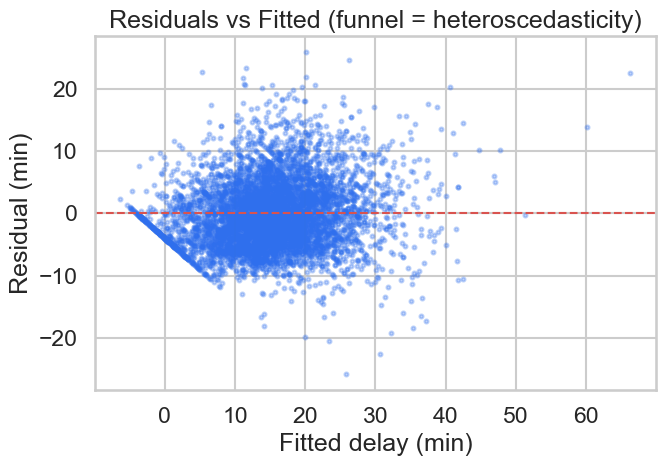

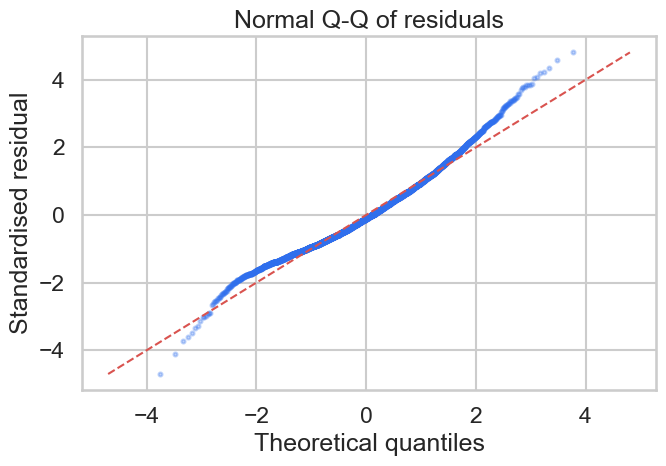

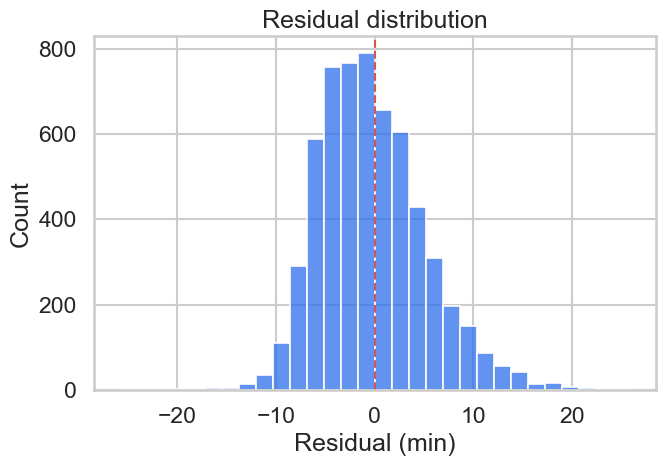

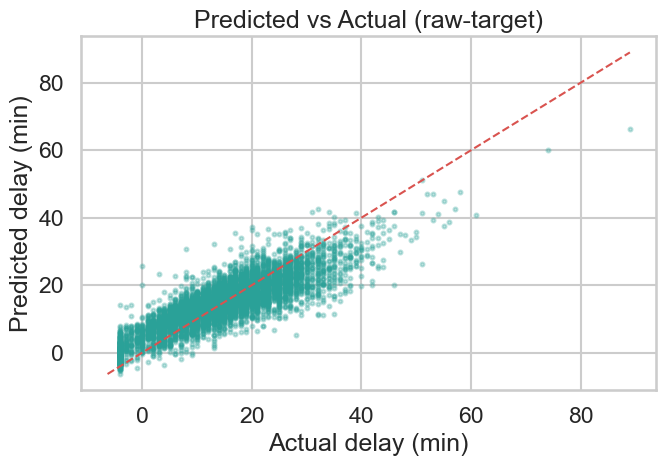

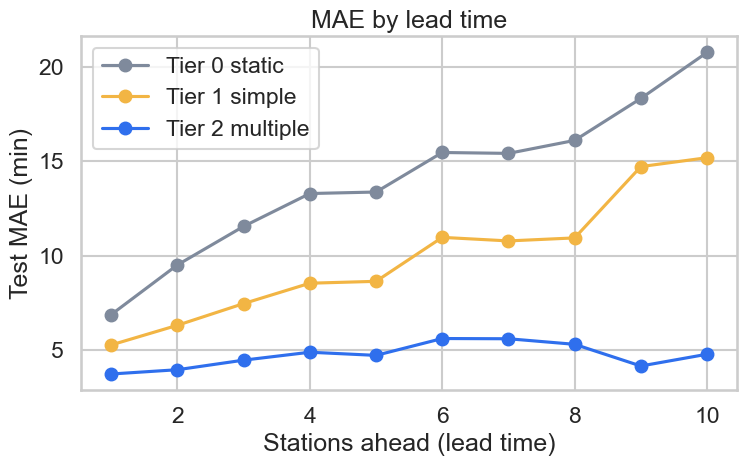

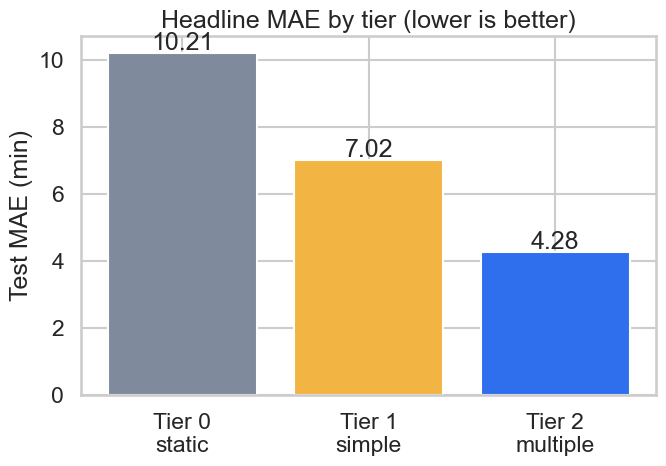

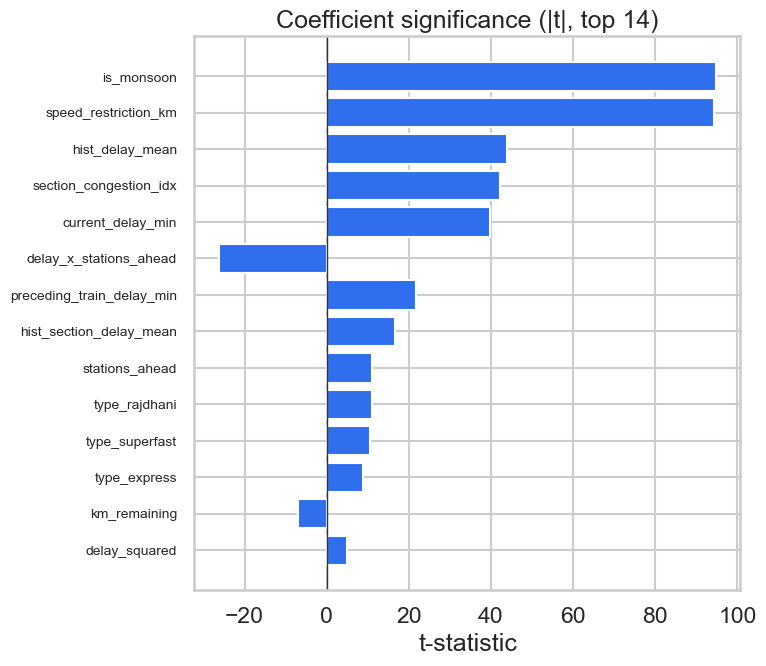

saved 7 plots to /Users/shubhammishra/Library/Application Support/Claude/local-agent-mode-sessions/1a4a9922-1325-4f5e-a782-1e69705a6539/f0b4273d-90da-4c3d-8764-3815f706624d/local_830c93e8-f97d-42d4-a211-d1db5e56178a/outputs/railcast/ml/plots


In [15]:
resid = y_te - pred_dep; fitted = pred_dep; DPI = 150
def save(fig, name):
    fig.tight_layout(); fig.savefig(os.path.join(PLOTS, name), dpi=DPI, bbox_inches="tight")

# 1 residuals vs fitted
fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(fitted, resid, s=8, alpha=0.3, color="#2f6fed"); ax.axhline(0, color="#d9534f", ls="--", lw=1.5)
ax.set(xlabel="Fitted delay (min)", ylabel="Residual (min)", title="Residuals vs Fitted (funnel = heteroscedasticity)")
save(fig, "residuals_vs_fitted.png"); plt.show()

# 2 normal Q-Q
fig, ax = plt.subplots(figsize=(7,5))
s = np.sort((resid - resid.mean())/resid.std(ddof=1)); n = len(s)
theo = np.array([statistics.NormalDist().inv_cdf((i+0.5)/n) for i in range(n)])
ax.scatter(theo, s, s=8, alpha=0.3, color="#2f6fed")
lim = [min(theo.min(), s.min()), max(theo.max(), s.max())]; ax.plot(lim, lim, color="#d9534f", ls="--", lw=1.5)
ax.set(xlabel="Theoretical quantiles", ylabel="Standardised residual", title="Normal Q-Q of residuals")
save(fig, "qq_residuals.png"); plt.show()

# 3 residual histogram
fig, ax = plt.subplots(figsize=(7,5)); sns.histplot(resid, bins=30, color="#2f6fed", ax=ax)
ax.axvline(0, color="#d9534f", ls="--", lw=1.5); ax.set(xlabel="Residual (min)", ylabel="Count", title="Residual distribution")
save(fig, "residual_hist.png"); plt.show()

# 4 predicted vs actual
fig, ax = plt.subplots(figsize=(7,5)); ax.scatter(y_te, pred_dep, s=8, alpha=0.3, color="#2aa198")
lim = [min(y_te.min(), pred_dep.min()), max(y_te.max(), pred_dep.max())]; ax.plot(lim, lim, color="#d9534f", ls="--", lw=1.5)
ax.set(xlabel="Actual delay (min)", ylabel="Predicted delay (min)", title=f"Predicted vs Actual ({chosen}-target)")
save(fig, "predicted_vs_actual.png"); plt.show()

# 5 MAE by lead
fig, ax = plt.subplots(figsize=(8,5))
ax.plot([d["lead"] for d in lead_static], [d["mae"] for d in lead_static], "-o", color="#7f8a9c", label="Tier 0 static")
ax.plot([d["lead"] for d in lead_simple], [d["mae"] for d in lead_simple], "-o", color="#f2b544", label="Tier 1 simple")
ax.plot([d["lead"] for d in lead_full],   [d["mae"] for d in lead_full],   "-o", color="#2f6fed", label="Tier 2 multiple")
ax.set(xlabel="Stations ahead (lead time)", ylabel="Test MAE (min)", title="MAE by lead time"); ax.legend()
save(fig, "mae_by_lead.png"); plt.show()

# 6 tier MAE comparison
fig, ax = plt.subplots(figsize=(7,5))
vals = [mae(err_static), mae(err_simple), mae(err_dep)]
bars = ax.bar(["Tier 0\nstatic","Tier 1\nsimple","Tier 2\nmultiple"], vals, color=["#7f8a9c","#f2b544","#2f6fed"])
for b,v in zip(bars, vals): ax.text(b.get_x()+b.get_width()/2, v+0.1, f"{v:.2f}", ha="center")
ax.set(ylabel="Test MAE (min)", title="Headline MAE by tier (lower is better)")
save(fig, "tier_mae_comparison.png"); plt.show()

# 7 coefficient significance
rows = sorted([c for c in coef_table if c["name"]!="intercept"], key=lambda c: abs(c["t"]), reverse=True)[:14]
fig, ax = plt.subplots(figsize=(8,7)); ys = np.arange(len(rows))[::-1]
ax.barh(ys, [c["t"] for c in rows], color=["#2f6fed" if c["p"]<0.05 else "#c9ccd1" for c in rows])
ax.set_yticks(ys); ax.set_yticklabels([c["name"] for c in rows], fontsize=10)
ax.axvline(0, color="#333", lw=1); ax.set(xlabel="t-statistic", title="Coefficient significance (|t|, top 14)")
save(fig, "coefficient_significance.png"); plt.show()
print("saved 7 plots to", PLOTS)

## 16 · Summary

Everything above is reproducible from `data/*.json`. Re-running this notebook overwrites the
exports the browser reads. The app never fits anything — it only takes dot products against
`model.json` and reads its numbers from `metrics.json`.